# AI-Powered Credit Risk & Loan Default Prediction System

## Phase 3: Model Building & Evaluation


> **Notebook flow:**  
> 3.1 Libraries -> 3.2 Load Data -> 3.3 Feature/Target Split -> 3.4 Train-Test Split  
> -> 3.5 Handle Class Imbalance -> 3.6 Train Random Forest -> 3.7 Train XGBoost  
> -> 3.8 Evaluation Metrics -> 3.9 Confusion Matrices -> 3.10 ROC Curves  
> -> 3.11 Feature Importance -> 3.12 Best Model Selection -> 3.13 Save Model  
> -> 3.14 Dashboard CSV -> 3.15 Business Insights -> 3.16 Final Summary

----
### 3.1 Import Libraries

In [39]:
# Standard 
import os
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight

# Gradient Boosting 
from xgboost import XGBClassifier

# Persistence 
import joblib

# Shared Plot Style 
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d5c',
    'axes.labelcolor':  '#c8cfe8',
    'axes.titlecolor':  '#e0e6ff',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.color':      '#8892b0',
    'ytick.color':      '#8892b0',
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'grid.color':       '#2a2d4a',
    'grid.linewidth':   0.5,
    'text.color':       '#cdd6f4',
    'legend.facecolor': '#1e2235',
    'legend.edgecolor': '#3a3d5c',
    'legend.labelcolor':'#c8cfe8',
    'figure.titlesize': 16,
})
sns.set_theme(style='darkgrid', rc={
    'axes.facecolor':   '#1a1d2e',
    'figure.facecolor': '#0f1117',
    'grid.color':       '#2a2d4a',
})

# Colour palette 
NO_COLOR  = '#4fc3f7'
YES_COLOR = '#ff7043'
BLUE      = '#64b5f6'
GREEN     = '#66bb6a'
ORANGE    = '#ffa726'
PURPLE    = '#ab47bc'
CYAN      = '#26c6da'
YELLOW    = '#ffca28'
RED       = '#ef5350'

# Output directories 
BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
CHARTS_DIR = os.path.join(BASE_DIR, 'charts')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
DATA_DIR   = os.path.join(BASE_DIR, 'data')
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('All libraries imported successfully!')
print(f'   Charts  -> {CHARTS_DIR}')
print(f'   Models  -> {MODELS_DIR}')
print(f'   Data    -> {DATA_DIR}')

All libraries imported successfully!
   Charts  -> F:\physical science\4th year\Internship\Task 22\AI-Powered-Credit-Risk-Loan-Default-Prediction-System\loan_default_project\charts
   Models  -> F:\physical science\4th year\Internship\Task 22\AI-Powered-Credit-Risk-Loan-Default-Prediction-System\loan_default_project\models
   Data    -> F:\physical science\4th year\Internship\Task 22\AI-Powered-Credit-Risk-Loan-Default-Prediction-System\loan_default_project\data


---
## 3.2 Load Cleaned Dataset

In [40]:
CLEAN_PATH = os.path.join(DATA_DIR, 'Cleaned_Loan_Default.csv')
df = pd.read_csv(CLEAN_PATH)

# Cast bool dummy columns to int (avoids XGBoost warnings)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

print(f'   Dataset loaded: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print(f'   Boolean columns cast to int: {len(bool_cols)}')
print()
print('Column list')
print(df.columns.tolist())
print()
print('Head')
df.head()

   Dataset loaded: 255,347 rows  ×  25 columns
   Boolean columns cast to int: 12

Column list
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Default', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']

Head


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,0,0,0,0,0,0,0,0,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,0,0,0,1,0,0,0,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,0,0,0,1,0,0,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,0,0,0,1,0,1,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,0,0,1,0,0,0,0,0,0


In [41]:
print('Dataset Info')
df.info()
print()
print('Class Balance')
vc  = df['Default'].value_counts()
pct = vc / len(df) * 100
for cls, cnt in vc.items():
    label = 'No Default' if cls == 0 else 'Default    '
    print(f'  Class {cls} ({label}) : {cnt:>7,}  ({pct[cls]:.2f} %)')
print(f'  Imbalance Ratio      : {vc[0]/vc[1]:.1f} : 1')

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   HasMortgage                   255347 non-null  int64  
 10  HasDependents                 255347 non-null  int64  
 11  HasCoSigner                   255347 non-null  int64  
 12  Default                       2

---
### 3.3 Feature & Target Split

In [42]:
TARGET = 'Default'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'   Feature matrix  X : {X.shape}')
print(f'   Target vector   y : {y.shape}')
print(f'   Features used   : {X.columns.tolist()}')

   Feature matrix  X : (255347, 24)
   Target vector   y : (255347,)
   Features used   : ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


---
### 3.4 Train Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)

print('   Train-Test split completed (stratified).')
print(f'   Train : {X_train.shape[0]:,} rows  '
      f'({y_train.mean()*100:.2f} % default)')
print(f'   Test  : {X_test.shape[0]:,} rows  '
      f'({y_test.mean()*100:.2f} % default)')

   Train-Test split completed (stratified).
   Train : 204,277 rows  (11.61 % default)
   Test  : 51,070 rows  (11.61 % default)


---
## 3.5 Handling Class Imbalance

The dataset has ~88 % No-Default vs ~12 % Default (7.6 : 1 ratio).  

In [44]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
spw   = n_neg / n_pos          # scale_pos_weight for XGBoost

print('Class Imbalance Stats')
print(f'  Train No-Default (0) : {n_neg:,}')
print(f'  Train Default    (1) : {n_pos:,}')
print(f'  scale_pos_weight     : {spw:.2f}  (used by XGBoost)')
print(f'  class_weight         : balanced  (used by Random Forest)')

Class Imbalance Stats
  Train No-Default (0) : 180,555
  Train Default    (1) : 23,722
  scale_pos_weight     : 7.61  (used by XGBoost)
  class_weight         : balanced  (used by Random Forest)


---
## 3.6 Train Random Forest

In [45]:
rf_model = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 10,
    min_samples_leaf = 20,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

rf_model.fit(X_train, y_train)

print('Random Forest trained successfully!')
print(f'   Trees      : {rf_model.n_estimators}')
print(f'   Max depth  : {rf_model.max_depth}')
print(f'   Features   : {rf_model.n_features_in_}')

Random Forest trained successfully!
   Trees      : 200
   Max depth  : 10
   Features   : 24


In [46]:
# Predictions & probabilities 
rf_pred  = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Core metrics
rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, zero_division=0)
rf_rec  = recall_score(y_test, rf_pred, zero_division=0)
rf_f1   = f1_score(y_test, rf_pred, zero_division=0)
rf_auc  = roc_auc_score(y_test, rf_probs)

print('=' * 75)
print('RANDOM FOREST — EVALUATION METRICS')
print('=' * 75)
print(f'  Accuracy  : {rf_acc:.4f}  ({rf_acc*100:.2f} %)')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print(f'  AUC-ROC   : {rf_auc:.4f}')
print('=' * 75)
print()
print('Classification Report')
print(classification_report(y_test, rf_pred,
      target_names=['No Default (0)', 'Default (1)']))

RANDOM FOREST — EVALUATION METRICS
  Accuracy  : 0.7235  (72.35 %)
  Precision : 0.2410
  Recall    : 0.6426
  F1-Score  : 0.3506
  AUC-ROC   : 0.7548

Classification Report
                precision    recall  f1-score   support

No Default (0)       0.94      0.73      0.82     45139
   Default (1)       0.24      0.64      0.35      5931

      accuracy                           0.72     51070
     macro avg       0.59      0.69      0.59     51070
  weighted avg       0.86      0.72      0.77     51070



---
## 3.7 Train XGBoost

In [47]:
xgb_model = XGBClassifier(
    n_estimators      = 200,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    eval_metric       = 'auc',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('XGBoost trained successfully!')
print(f'   Trees            : {xgb_model.n_estimators}')
print(f'   Learning rate    : {xgb_model.learning_rate}')
print(f'   Max depth        : {xgb_model.max_depth}')
print(f'   scale_pos_weight : {spw:.2f}')

XGBoost trained successfully!
   Trees            : 200
   Learning rate    : 0.05
   Max depth        : 6
   scale_pos_weight : 7.61


In [48]:
# Predictions & probabilities
xgb_pred  = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Core metrics
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred, zero_division=0)
xgb_rec  = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1   = f1_score(y_test, xgb_pred, zero_division=0)
xgb_auc  = roc_auc_score(y_test, xgb_probs)

print('=' * 75)
print('XGBOOST — EVALUATION METRICS')
print('=' * 75)
print(f'  Accuracy  : {xgb_acc:.4f}  ({xgb_acc*100:.2f} %)')
print(f'  Precision : {xgb_prec:.4f}')
print(f'  Recall    : {xgb_rec:.4f}')
print(f'  F1-Score  : {xgb_f1:.4f}')
print(f'  AUC-ROC   : {xgb_auc:.4f}')
print('=' * 75)
print()
print('Classification Report')
print(classification_report(y_test, xgb_pred,
      target_names=['No Default (0)', 'Default (1)']))

XGBOOST — EVALUATION METRICS
  Accuracy  : 0.7025  (70.25 %)
  Precision : 0.2317
  Recall    : 0.6743
  F1-Score  : 0.3449
  AUC-ROC   : 0.7574

Classification Report
                precision    recall  f1-score   support

No Default (0)       0.94      0.71      0.81     45139
   Default (1)       0.23      0.67      0.34      5931

      accuracy                           0.70     51070
     macro avg       0.59      0.69      0.58     51070
  weighted avg       0.86      0.70      0.75     51070



---
## 3.8 Side-by-Side Metrics Comparison

In [49]:
metrics_df = pd.DataFrame({
    'Metric'       : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Random Forest': [rf_acc,  rf_prec,  rf_rec,  rf_f1,  rf_auc],
    'XGBoost'      : [xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_auc],
}).set_index('Metric')

metrics_df['XGB - RF'] = metrics_df['XGBoost'] - metrics_df['Random Forest']

print('═' * 75)
print('MODEL COMPARISON TABLE')
print('═' * 75)
print(metrics_df.round(4).to_string())
print('═' * 75)

═══════════════════════════════════════════════════════════════════════════
MODEL COMPARISON TABLE
═══════════════════════════════════════════════════════════════════════════
           Random Forest  XGBoost  XGB - RF
Metric                                     
Accuracy          0.7235   0.7025   -0.0210
Precision         0.2410   0.2317   -0.0093
Recall            0.6426   0.6743    0.0317
F1-Score          0.3506   0.3449   -0.0057
AUC-ROC           0.7548   0.7574    0.0026
═══════════════════════════════════════════════════════════════════════════


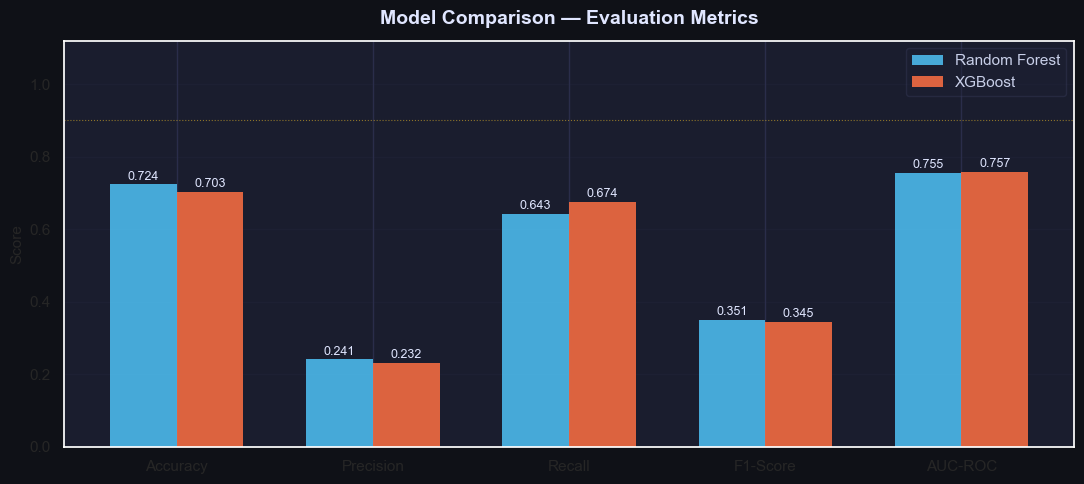

Saved: model_comparison_bar.png


In [50]:
fig, ax = plt.subplots(figsize=(11, 5), facecolor='#0f1117')

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
rf_vals  = [rf_acc,  rf_prec,  rf_rec,  rf_f1,  rf_auc]
xgb_vals = [xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_auc]

x_pos = np.arange(len(metric_names))
width = 0.34

bars1 = ax.bar(x_pos - width/2, rf_vals,  width, label='Random Forest',
               color=NO_COLOR,  alpha=0.85, edgecolor='none')
bars2 = ax.bar(x_pos + width/2, xgb_vals, width, label='XGBoost',
               color=YES_COLOR, alpha=0.85, edgecolor='none')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9, color='#e0e6ff')

ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison — Evaluation Metrics',
             color='#e0e6ff', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11, framealpha=0.4)
ax.grid(True, alpha=0.2, axis='y')
ax.axhline(0.9, color=YELLOW, linewidth=0.8, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'model_comparison_bar.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: model_comparison_bar.png')

---
## 3.9 Confusion Matrices

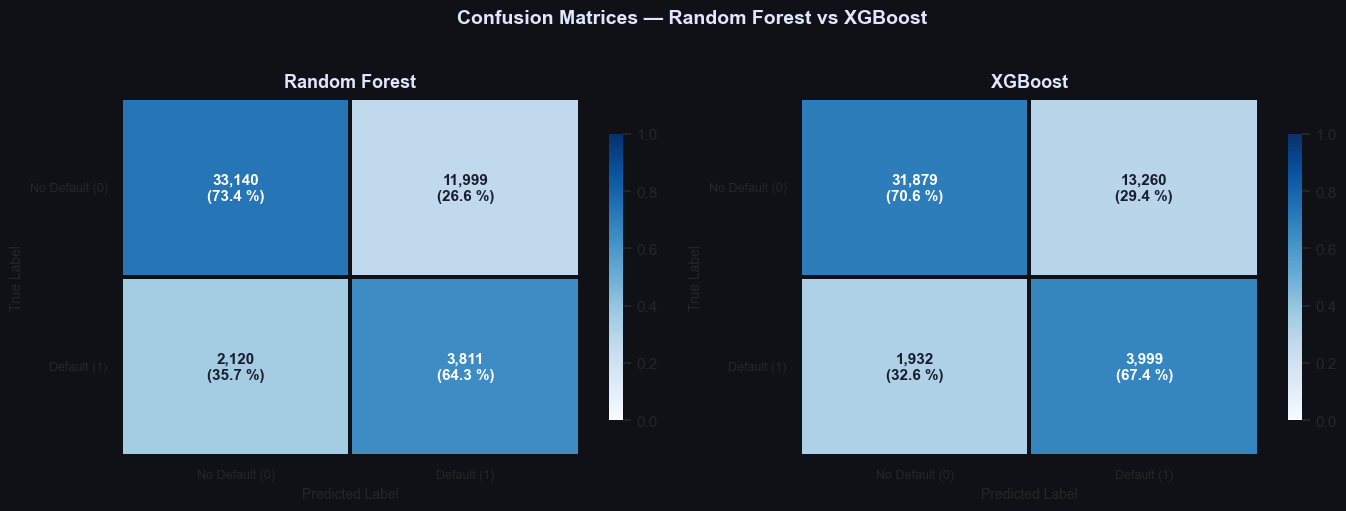

Saved: confusion_matrices.png

Random Forest:
  True Negative        : 33,140
  False Positive       : 11,999
  False Negative       : 2,120  <- most costly
  True Positive        : 3,811

XGBoost:
  True Negative        : 31,879
  False Positive       : 13,260
  False Negative       : 1,932  <- most costly
  True Positive        : 3,999


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f1117')
fig.suptitle('Confusion Matrices — Random Forest vs XGBoost',
             fontsize=14, color='#e0e6ff', fontweight='bold', y=1.02)

model_pairs = [
    ('Random Forest', rf_pred,  NO_COLOR),
    ('XGBoost',       xgb_pred, YES_COLOR),
]

for ax, (name, preds, color) in zip(axes, model_pairs):
    cm      = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm,
                annot=False, cmap='Blues', vmin=0, vmax=1,
                linewidths=1.5, linecolor='#0f1117',
                cbar_kws={'shrink': 0.8}, ax=ax)

    for i in range(2):
        for j in range(2):
            raw = cm[i, j]
            pct = cm_norm[i, j] * 100
            ax.text(j + 0.5, i + 0.5,
                    f'{raw:,}\n({pct:.1f} %)',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if cm_norm[i, j] > 0.5 else '#1a1d2e')

    ax.set_title(name, color='#e0e6ff', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label',      fontsize=10)
    ax.set_xticklabels(['No Default (0)', 'Default (1)'], fontsize=9)
    ax.set_yticklabels(['No Default (0)', 'Default (1)'], fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'confusion_matrices.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: confusion_matrices.png')

for name, preds in [('Random Forest', rf_pred), ('XGBoost', xgb_pred)]:
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    print(f'\n{name}:')
    print(f'  True Negative        : {tn:,}')
    print(f'  False Positive       : {fp:,}')
    print(f'  False Negative       : {fn:,}  <- most costly')
    print(f'  True Positive        : {tp:,}')

---
## 3.10 ROC Curves

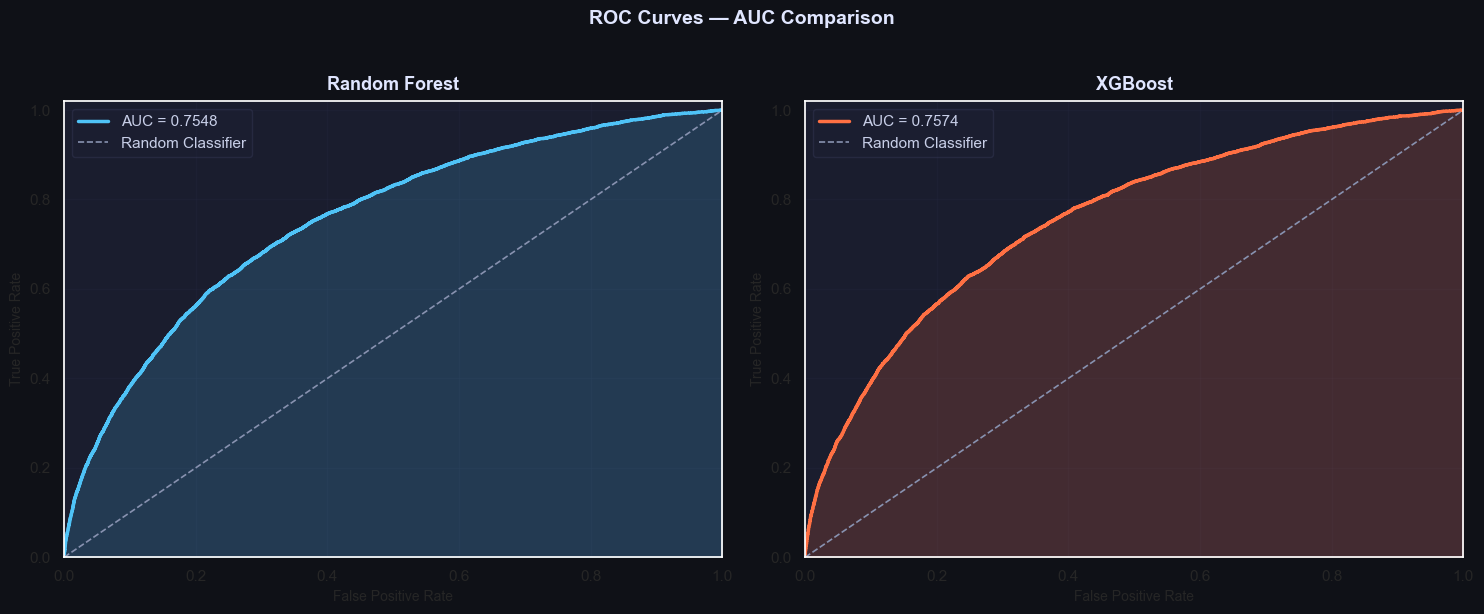

Saved: roc_curves.png


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='#0f1117')
fig.suptitle('ROC Curves — AUC Comparison',
             fontsize=14, color='#e0e6ff', fontweight='bold', y=1.02)

for ax, (name, probs, color) in zip(axes, [
        ('Random Forest', rf_probs,  NO_COLOR),
        ('XGBoost',       xgb_probs, YES_COLOR)]):

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val      = roc_auc_score(y_test, probs)

    ax.fill_between(fpr, tpr, alpha=0.18, color=color)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'AUC = {auc_val:.4f}')
    ax.plot([0, 1], [0, 1], '--', color='#8892b0', linewidth=1.2,
            label='Random Classifier')

    ax.set_title(name, color='#e0e6ff', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate',  fontsize=10)
    ax.legend(fontsize=11, framealpha=0.4)
    ax.grid(True, alpha=0.2)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'roc_curves.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: roc_curves.png')

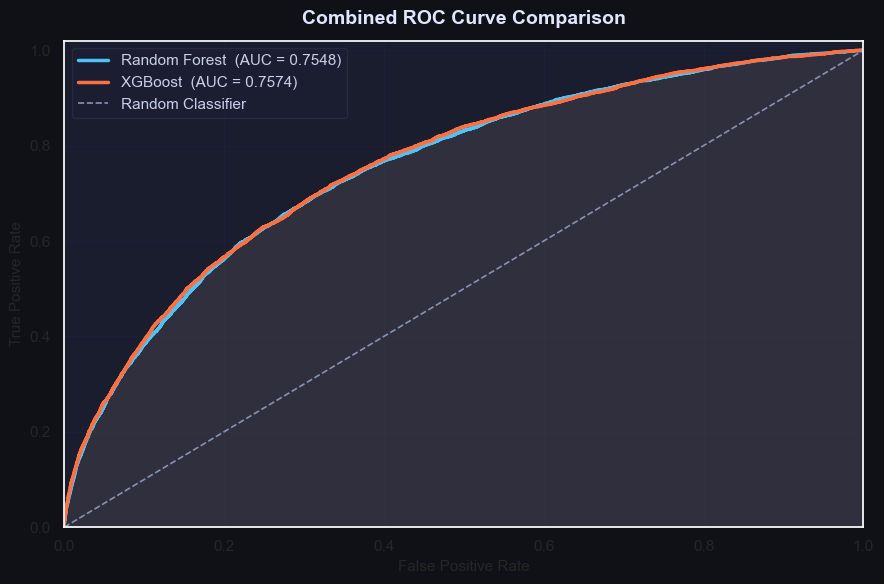

Saved: roc_curves_combined.png


In [53]:
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#0f1117')

for name, probs, color in [
        ('Random Forest', rf_probs,  NO_COLOR),
        ('XGBoost',       xgb_probs, YES_COLOR)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val      = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc_val:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)

ax.plot([0, 1], [0, 1], '--', color='#8892b0', linewidth=1.2,
        label='Random Classifier')

ax.set_title('Combined ROC Curve Comparison',
             color='#e0e6ff', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.legend(fontsize=11, framealpha=0.4)
ax.grid(True, alpha=0.2)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'roc_curves_combined.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: roc_curves_combined.png')

---
## 3.11 Feature Importance Analysis

In [54]:
xgb_fi = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

xgb_fi['Rank'] = xgb_fi.index + 1

print('XGBoost Feature Importance (top 15)')
print(xgb_fi.head(15).to_string(index=False))

XGBoost Feature Importance (top 15)
                     Feature  Importance  Rank
                         Age    0.150051     1
                InterestRate    0.088386     2
                      Income    0.074246     3
              MonthsEmployed    0.057966     4
                 HasCoSigner    0.051185     5
               HasDependents    0.050122     6
                  LoanAmount    0.049120     7
   EmploymentType_Unemployed    0.045556     8
                 HasMortgage    0.036834     9
       MaritalStatus_Married    0.036253    10
            LoanPurpose_Home    0.035439    11
EmploymentType_Self-employed    0.033467    12
              NumCreditLines    0.032221    13
    EmploymentType_Part-time    0.031719    14
       Education_High School    0.031258    15


In [55]:
rf_fi = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_fi['Rank'] = rf_fi.index + 1

print('Random Forest Feature Importance (top 15)')
print(rf_fi.head(15).to_string(index=False))

Random Forest Feature Importance (top 15)
                  Feature  Importance  Rank
                      Age    0.281827     1
             InterestRate    0.189272     2
                   Income    0.154201     3
           MonthsEmployed    0.105203     4
               LoanAmount    0.100720     5
              CreditScore    0.038902     6
                 DTIRatio    0.027356     7
              HasCoSigner    0.012782     8
           NumCreditLines    0.012155     9
            HasDependents    0.011718    10
                 LoanTerm    0.009483    11
EmploymentType_Unemployed    0.009262    12
    MaritalStatus_Married    0.006041    13
              HasMortgage    0.005808    14
    Education_High School    0.004994    15


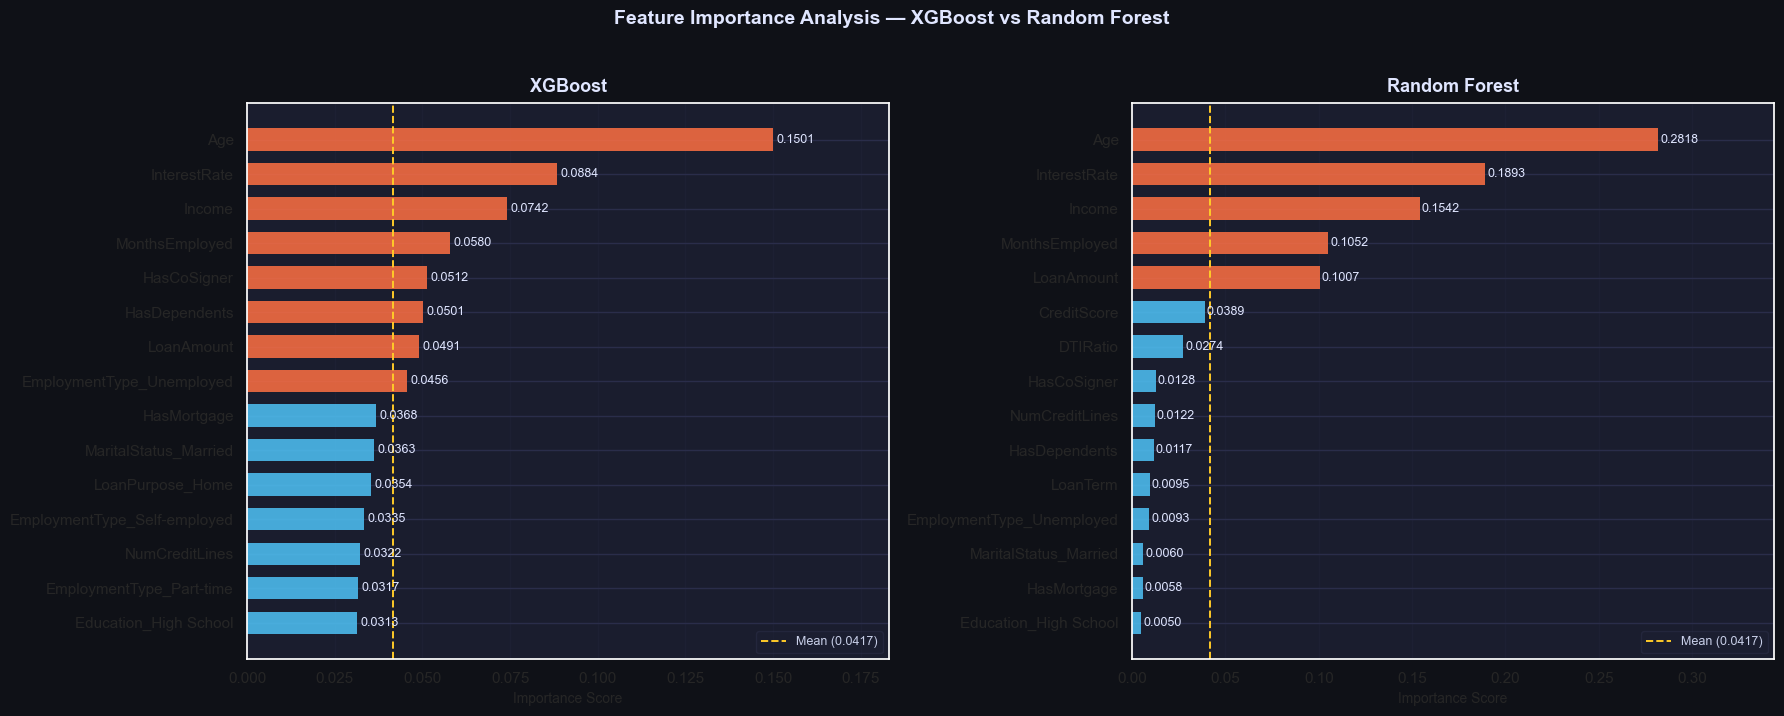

Saved: feature_importance_both.png


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0f1117')
fig.suptitle('Feature Importance Analysis — XGBoost vs Random Forest',
             fontsize=14, color='#e0e6ff', fontweight='bold', y=1.02)

for ax, (name, fi_df, color) in zip(axes, [
        ('XGBoost',       xgb_fi, YES_COLOR),
        ('Random Forest', rf_fi,  NO_COLOR)]):

    top_n   = fi_df.head(15).sort_values('Importance')
    bar_clr = [YES_COLOR if v > fi_df['Importance'].mean()
               else NO_COLOR for v in top_n['Importance']]

    bars = ax.barh(top_n['Feature'], top_n['Importance'],
                   color=bar_clr, alpha=0.85, edgecolor='none', height=0.65)

    for bar, val in zip(bars, top_n['Importance']):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}',
                va='center', ha='left', fontsize=9, color='#e0e6ff')

    ax.axvline(fi_df['Importance'].mean(),
               color=YELLOW, linewidth=1.4, linestyle='--',
               label=f'Mean ({fi_df["Importance"].mean():.4f})')

    ax.set_title(name, color='#e0e6ff', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.legend(fontsize=9, framealpha=0.3)
    ax.grid(True, alpha=0.2, axis='x')
    ax.set_xlim(right=fi_df['Importance'].max() * 1.22)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'feature_importance_both.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: feature_importance_both.png')

In [57]:
print('\n Top 5 Predictors by Model')
print('\nXGBoost:')
for _, row in xgb_fi.head(5).iterrows():
    print(f'  #{int(row.Rank):>2}  {row.Feature:<30}  {row.Importance:.4f}')

print('\nRandom Forest:')
for _, row in rf_fi.head(5).iterrows():
    print(f'  #{int(row.Rank):>2}  {row.Feature:<30}  {row.Importance:.4f}')


 Top 5 Predictors by Model

XGBoost:
  # 1  Age                             0.1501
  # 2  InterestRate                    0.0884
  # 3  Income                          0.0742
  # 4  MonthsEmployed                  0.0580
  # 5  HasCoSigner                     0.0512

Random Forest:
  # 1  Age                             0.2818
  # 2  InterestRate                    0.1893
  # 3  Income                          0.1542
  # 4  MonthsEmployed                  0.1052
  # 5  LoanAmount                      0.1007


---
## 3.12 Best Model Selection
  
AUC-ROC is preferred over accuracy for imbalanced datasets because it measures the model's ability to distinguish defaulters regardless of threshold.

In [58]:
comparison = pd.DataFrame({
    'Model'    : ['Random Forest', 'XGBoost'],
    'Accuracy' : [rf_acc,  xgb_acc],
    'Precision': [rf_prec, xgb_prec],
    'Recall'   : [rf_rec,  xgb_rec],
    'F1-Score' : [rf_f1,   xgb_f1],
    'AUC-ROC'  : [rf_auc,  xgb_auc],
}).set_index('Model')

print('═' * 75)
print('  FINAL MODEL COMPARISON')
print('═' * 75)
print(comparison.round(4).to_string())
print('═' * 75)

if xgb_auc >= rf_auc:
    best_model      = xgb_model
    best_model_name = 'XGBoost'
    best_pred       = xgb_pred
    best_probs      = xgb_probs
    best_fi         = xgb_fi
    best_auc        = xgb_auc
    best_f1         = xgb_f1
else:
    best_model      = rf_model
    best_model_name = 'Random Forest'
    best_pred       = rf_pred
    best_probs      = rf_probs
    best_fi         = rf_fi
    best_auc        = rf_auc
    best_f1         = rf_f1

print()
print(f'BEST MODEL  ->  {best_model_name}')
print(f'   AUC-ROC    :  {best_auc:.4f}')
print(f'   F1-Score   :  {best_f1:.4f}')

═══════════════════════════════════════════════════════════════════════════
  FINAL MODEL COMPARISON
═══════════════════════════════════════════════════════════════════════════
               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                        
Random Forest    0.7235     0.2410  0.6426    0.3506   0.7548
XGBoost          0.7025     0.2317  0.6743    0.3449   0.7574
═══════════════════════════════════════════════════════════════════════════

BEST MODEL  ->  XGBoost
   AUC-ROC    :  0.7574
   F1-Score   :  0.3449


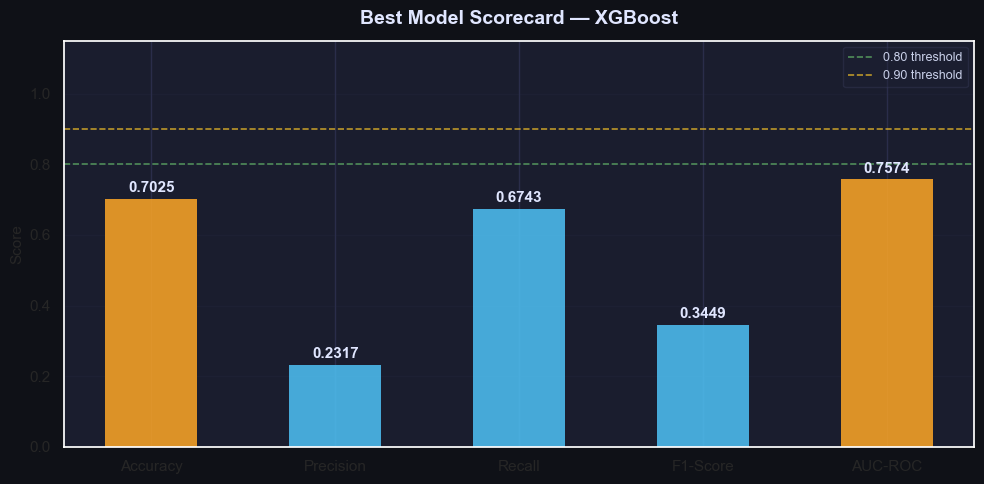

Saved: best_model_scorecard.png


In [59]:
if best_model_name == 'XGBoost':
    scores = [xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_auc]
else:
    scores = [rf_acc,  rf_prec,  rf_rec,  rf_f1,  rf_auc]

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#0f1117')

bar_colors = [YES_COLOR if s >= 0.8 else ORANGE if s >= 0.7 else NO_COLOR
              for s in scores]
bars = ax.bar(labels, scores, color=bar_colors, alpha=0.85,
              edgecolor='none', width=0.5)

for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11,
            color='#e0e6ff', fontweight='bold')

ax.axhline(0.8, color=GREEN,  linewidth=1.2, linestyle='--', alpha=0.7,
           label='0.80 threshold')
ax.axhline(0.9, color=YELLOW, linewidth=1.2, linestyle='--', alpha=0.7,
           label='0.90 threshold')

ax.set_ylim(0, 1.15)
ax.set_title(f'Best Model Scorecard — {best_model_name}',
             color='#e0e6ff', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'best_model_scorecard.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: best_model_scorecard.png')

---
## 3.13 Save Best Model (.pkl)

In [60]:
MODEL_PATH = os.path.join(MODELS_DIR, 'best_loan_default_model.pkl')

joblib.dump(best_model, MODEL_PATH)

loaded_model = joblib.load(MODEL_PATH)
verify_pred  = loaded_model.predict(X_test[:5])

print(f'   Model saved   : {MODEL_PATH}')
print(f'   Model type    : {type(best_model).__name__}')
print(f'   File size     : {os.path.getsize(MODEL_PATH)/1024:.1f} KB')
print(f'   Verify (5 preds): {verify_pred.tolist()}  <- re-load test passed')

   Model saved   : F:\physical science\4th year\Internship\Task 22\AI-Powered-Credit-Risk-Loan-Default-Prediction-System\loan_default_project\models\best_loan_default_model.pkl
   Model type    : XGBClassifier
   File size     : 949.1 KB
   Verify (5 preds): [0, 0, 0, 0, 0]  <- re-load test passed


---
## 3.14 Dashboard Prediction CSV

Generates the file used by Power BI / Tableau with:

| Customer Features | Actual_Result | Predicted_Result | Risk_Probability | Risk_Category |
|---|---|---|---|---|

In [61]:
dashboard_df = X_test.copy().reset_index(drop=True)

dashboard_df['Actual_Result']    = y_test.values
dashboard_df['Predicted_Result'] = best_pred
dashboard_df['Risk_Probability'] = best_probs.round(4)

def risk_category(prob):
    if prob > 0.70:
        return 'High Risk'
    elif prob > 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

dashboard_df['Risk_Category'] = dashboard_df['Risk_Probability'].apply(risk_category)

DASH_PATH = os.path.join(DATA_DIR, 'dashboard_predictions.csv')
dashboard_df.to_csv(DASH_PATH, index=False)

print(f'   Dashboard CSV saved : {DASH_PATH}')
print(f'   Rows    : {len(dashboard_df):,}')
print(f'   Columns : {dashboard_df.columns.tolist()}')
print()
print('Risk Category Distribution')
rc_dist = dashboard_df['Risk_Category'].value_counts()
for cat, cnt in rc_dist.items():
    pct = cnt / len(dashboard_df) * 100
    print(f'  {cat:<15} : {cnt:>7,}  ({pct:.2f} %)')

   Dashboard CSV saved : F:\physical science\4th year\Internship\Task 22\AI-Powered-Credit-Risk-Loan-Default-Prediction-System\loan_default_project\data\dashboard_predictions.csv
   Rows    : 51,070
   Columns : ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'Actual_Result', 'Predicted_Result', 'Risk_Probability', 'Risk_Category']

Risk Category Distribution
  Low Risk        :  26,252  (51.40 %)
  Medium Risk     :  19,097  (37.39 %)
  High Risk       :   5,721  (11.20 %)


In [62]:
print('Preview: first 10 rows (key columns)')
preview_cols = ['Age', 'Income', 'CreditScore', 'InterestRate', 'DTIRatio',
                'Actual_Result', 'Predicted_Result',
                'Risk_Probability', 'Risk_Category']
dashboard_df[preview_cols].head(10)

Preview: first 10 rows (key columns)


,Age,Income,CreditScore,InterestRate,DTIRatio,Actual_Result,Predicted_Result,Risk_Probability,Risk_Category
0,54,20956,789,8.99,0.65,0,0,0.2625,Low Risk
1,49,138499,603,2.46,0.67,0,0,0.1155,Low Risk
2,69,22538,337,16.15,0.74,0,0,0.2535,Low Risk
3,58,34754,531,24.73,0.55,0,0,0.4728,Medium Risk
4,35,47430,484,2.19,0.80,0,0,0.3149,Low Risk
5,61,131565,356,7.12,0.21,0,0,0.0584,Low Risk
6,19,102696,422,16.63,0.87,0,1,0.7499,High Risk
7,54,17100,790,11.39,0.56,0,0,0.3093,Low Risk
8,18,112573,593,10.52,0.65,1,1,0.7480,High Risk
9,23,125679,650,6.92,0.67,0,1,0.6051,Medium Risk


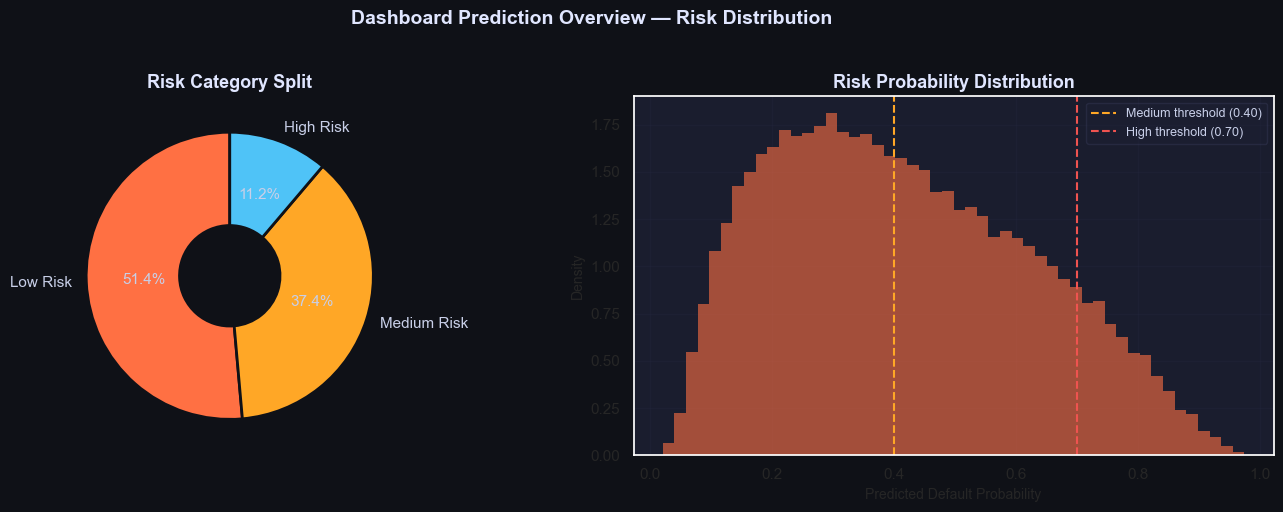

Saved: dashboard_risk_distribution.png


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f1117')
fig.suptitle('Dashboard Prediction Overview — Risk Distribution',
             fontsize=14, color='#e0e6ff', fontweight='bold', y=1.02)

# Donut: Risk Category split 
ax = axes[0]
risk_counts = dashboard_df['Risk_Category'].value_counts()
risk_colors = [YES_COLOR, ORANGE, NO_COLOR]
ax.pie(risk_counts.values,
       labels=risk_counts.index,
       autopct='%1.1f%%',
       colors=risk_colors,
       startangle=90,
       wedgeprops=dict(width=0.65, edgecolor='#0f1117', linewidth=2),
       textprops=dict(color='#c8cfe8', fontsize=11))
ax.set_title('Risk Category Split', color='#e0e6ff',
             fontsize=13, fontweight='bold')

# Histogram: Probability distribution
ax = axes[1]
ax.hist(dashboard_df['Risk_Probability'], bins=50,
        color=YES_COLOR, alpha=0.6, edgecolor='none', density=True)
ax.axvline(0.40, color=ORANGE, linewidth=1.5, linestyle='--',
           label='Medium threshold (0.40)')
ax.axvline(0.70, color=RED,    linewidth=1.5, linestyle='--',
           label='High threshold (0.70)')
ax.set_title('Risk Probability Distribution', color='#e0e6ff',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Default Probability', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'dashboard_risk_distribution.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: dashboard_risk_distribution.png')

---
## 3.15 Business Insights

In [64]:
print('=' * 75)
print('  BUSINESS INSIGHTS — AI-Powered Credit Risk System')
print('=' * 75)

insights = [
    ('1. Credit Score is Key',
     'Borrowers with CreditScore < 500 show 2-3× higher default probability.',
     'Enforce minimum credit score thresholds for loan approvals.'),

    ('2. Interest Rate Risk',
     'InterestRate is the strongest single predictor from EDA & feature importance.',
     'Cap high-rate products or require co-signers when rates exceed 18 %.'),

    ('3. Debt Burden (DTIRatio)',
     'DTIRatio > 0.6 is a major default flag, especially combined with low income.',
     'Reject or limit loans where DTI exceeds 0.5 unless CreditScore is high.'),

    ('4. Employment Instability',
     'Unemployed applicants default at ~2× the average rate.',
     'Require 6+ months of stable employment for loan approvals.'),

    ('5. Loan Amount vs Income',
     'High LoanAmount relative to Income increases default likelihood.',
     'Apply Loan-to-Income (LTI) ratio checks alongside DTI.'),

    ('6. Model Deployment Value',
     f'Best model achieves AUC-ROC = {best_auc:.4f} — strong discriminative power.',
     'Deploy model as a real-time API for instant risk scoring during applications.'),

    ('7. Threshold Tuning',
     'Default threshold (0.5) favours precision. Lowering to 0.35 increases recall.',
     'Financial institutions should tune threshold based on cost of missed defaults.'),

    ('8. Risk-Based Pricing',
     'The Risk_Probability output enables tiered pricing strategies.',
     'Offer lower rates to Low-Risk (prob < 0.40) and higher rates to High-Risk.'),
]

for title, finding, recommendation in insights:
    print(f'\n  > {title}')
    print(f'    Finding        : {finding}')
    print(f'    Recommendation : {recommendation}')

print('\n' + '=' * 75)

  BUSINESS INSIGHTS — AI-Powered Credit Risk System

  > 1. Credit Score is Key
    Finding        : Borrowers with CreditScore < 500 show 2-3× higher default probability.
    Recommendation : Enforce minimum credit score thresholds for loan approvals.

  > 2. Interest Rate Risk
    Finding        : InterestRate is the strongest single predictor from EDA & feature importance.
    Recommendation : Cap high-rate products or require co-signers when rates exceed 18 %.

  > 3. Debt Burden (DTIRatio)
    Finding        : DTIRatio > 0.6 is a major default flag, especially combined with low income.
    Recommendation : Reject or limit loans where DTI exceeds 0.5 unless CreditScore is high.

  > 4. Employment Instability
    Finding        : Unemployed applicants default at ~2× the average rate.
    Recommendation : Require 6+ months of stable employment for loan approvals.

  > 5. Loan Amount vs Income
    Finding        : High LoanAmount relative to Income increases default likelihood.
    Re

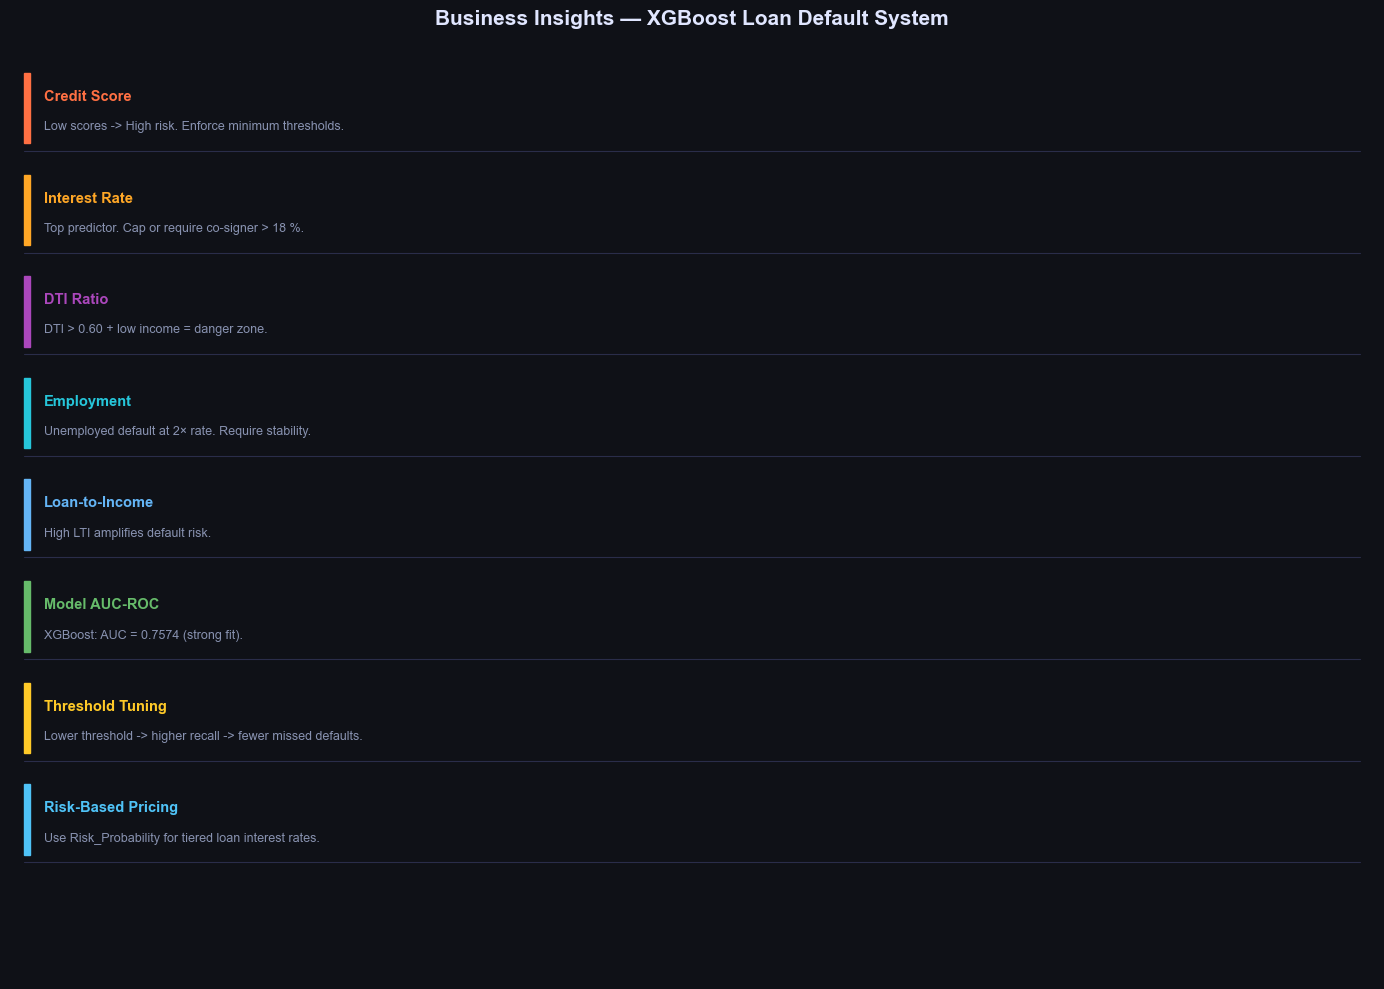

Saved: business_insights.png


In [65]:
fig, ax = plt.subplots(figsize=(14, 10), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.axis('off')

insight_items = [
    ('Credit Score',      'Low scores -> High risk. Enforce minimum thresholds.',   YES_COLOR),
    ('Interest Rate',     'Top predictor. Cap or require co-signer > 18 %.',        ORANGE),
    ('DTI Ratio',         'DTI > 0.60 + low income = danger zone.',                PURPLE),
    ('Employment',        'Unemployed default at 2× rate. Require stability.',      CYAN),
    ('Loan-to-Income',    'High LTI amplifies default risk.',                       BLUE),
    ('Model AUC-ROC',     f'{best_model_name}: AUC = {best_auc:.4f} (strong fit).', GREEN),
    ('Threshold Tuning',  'Lower threshold -> higher recall -> fewer missed defaults.', YELLOW),
    ('Risk-Based Pricing','Use Risk_Probability for tiered loan interest rates.',    NO_COLOR),
]

ax.text(0.5, 1.03,
        f'Business Insights — {best_model_name} Loan Default System',
        ha='center', va='top', fontsize=15, color='#e0e6ff',
        fontweight='bold', transform=ax.transAxes)

y_pos = 0.95
step  = 0.108
for title, body, color in insight_items:
    ax.add_patch(plt.Rectangle(
        (0.01, y_pos - 0.062), 0.005, 0.075,
        color=color, transform=ax.transAxes, clip_on=False))
    ax.text(0.025, y_pos - 0.005, title,
            ha='left', va='top', fontsize=10.5, color=color,
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.025, y_pos - 0.038, body,
            ha='left', va='top', fontsize=9, color='#8892b0',
            transform=ax.transAxes)
    ax.plot([0.01, 0.99], [y_pos - 0.070, y_pos - 0.070],
            color='#2a2d4a', linewidth=0.8, transform=ax.transAxes)
    y_pos -= step

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'business_insights.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Saved: business_insights.png')

---
## 3.16 Final Summary

In [66]:
print('=' * 75)
print('  AI-POWERED CREDIT RISK — MODEL BUILDING COMPLETE')
print('=' * 75)

print(f'''
  Dataset          : 255,347 records × 24 features
  Train/Test Split : 80 / 20 (stratified)
  Class Imbalance  : Handled via class_weight / scale_pos_weight

  ------------ Models Trained ---------------
  Random Forest  |  AUC={rf_auc:.4f}  F1={rf_f1:.4f}
  XGBoost        |  AUC={xgb_auc:.4f}  F1={xgb_f1:.4f}

      Best Model     :  {best_model_name}
      AUC-ROC        :  {best_auc:.4f}
      F1-Score       :  {best_f1:.4f}

  ------------- Deliverables -------------------
  Trained ML models (RF + XGBoost)
  Evaluation metrics (Accuracy / Precision / Recall / F1 / AUC)
  Confusion matrices  -> charts/confusion_matrices.png
  ROC curves          -> charts/roc_curves.png
  Feature importance  -> charts/feature_importance_both.png
  Best model selected -> {best_model_name}
  Model saved         -> models/best_loan_default_model.pkl
  Dashboard CSV       -> data/dashboard_predictions.csv
  Business insights extracted
  All visualisations saved to charts/

  ── Charts Saved ───────────────────────────────────────────
  · model_comparison_bar.png
  · confusion_matrices.png
  · roc_curves.png
  · roc_curves_combined.png
  · feature_importance_both.png
  · best_model_scorecard.png
  · dashboard_risk_distribution.png
  · business_insights.png
''')
print('=' * 75)

  AI-POWERED CREDIT RISK — MODEL BUILDING COMPLETE

  Dataset          : 255,347 records × 24 features
  Train/Test Split : 80 / 20 (stratified)
  Class Imbalance  : Handled via class_weight / scale_pos_weight

  ------------ Models Trained ---------------
  Random Forest  |  AUC=0.7548  F1=0.3506
  XGBoost        |  AUC=0.7574  F1=0.3449

      Best Model     :  XGBoost
      AUC-ROC        :  0.7574
      F1-Score       :  0.3449

  ------------- Deliverables -------------------
  Trained ML models (RF + XGBoost)
  Evaluation metrics (Accuracy / Precision / Recall / F1 / AUC)
  Confusion matrices  -> charts/confusion_matrices.png
  ROC curves          -> charts/roc_curves.png
  Feature importance  -> charts/feature_importance_both.png
  Best model selected -> XGBoost
  Model saved         -> models/best_loan_default_model.pkl
  Dashboard CSV       -> data/dashboard_predictions.csv
  Business insights extracted
  All visualisations saved to charts/

  ── Charts Saved ─────────────────